In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sqlite3
import pycountry
import geopandas as gpd
from matplotlib.colors import LogNorm

In [2]:
connection = sqlite3.connect(
    r".\database.sqlite"
)

cursor = connection.cursor()

tables = ["account", "iap_purchase", "account_date_session"]

for table in tables:

    print(f"\n{'=' * 50}")
    print(f"TABLE: {table}")
    print(f"{'=' * 50}")

    # Column names
    cursor.execute(f"PRAGMA table_info('{table}')")
    columns = cursor.fetchall()

    print("Columns:")
    for column in columns:
        print(f"  {column[1]}")

    # Number of rows
    cursor.execute(f"SELECT COUNT(*) FROM '{table}'")
    row_count = cursor.fetchone()[0]

    print(f"Rows: {row_count}")

connection.close()


TABLE: account
Columns:
  account_id
  created_time
  created_device
  created_platform
  country_code
  created_app_store_id
Rows: 112792

TABLE: iap_purchase
Columns:
  account_id
  created_time
  package_id_hash
  iap_price_usd_cents
  app_store_id
Rows: 9909

TABLE: account_date_session
Columns:
  account_id
  date
  session_count
  session_duration_sec
Rows: 1698974


                 ACCOUNT
             👤 Players
            112,792 rows
                  │
          account_id
          ┌───────┴────────┐
          ↓                ↓
   PLAYER ACTIVITY      PURCHASES
   📱 Sessions           💰 IAP
   1.7M rows             9.9K rows

   👤 Who are they?

   🎮 How do they play?
   
   💰 Do they pay?



In [5]:

connection = sqlite3.connect(
    r".\database.sqlite"
)

cursor = connection.cursor()

# 1. Duplicate accounts
cursor.execute("""
    SELECT 
        COUNT(*) AS total_rows,
        COUNT(DISTINCT account_id) AS unique_accounts
    FROM account;
""")

print("ACCOUNT:")
print(cursor.fetchone())


# 2. Purchases without matching account
cursor.execute("""
    SELECT COUNT(*)
    FROM iap_purchase p
    LEFT JOIN account a
        ON p.account_id = a.account_id
    WHERE a.account_id IS NULL;
""")

print("\nPURCHASES without matching ACCOUNT:")
print(cursor.fetchone()[0])


# 3. Sessions without matching account
cursor.execute("""
    SELECT COUNT(*)
    FROM account_date_session s
    LEFT JOIN account a
        ON s.account_id = a.account_id
    WHERE a.account_id IS NULL;
""")

print("\nSESSIONS without matching ACCOUNT:")
print(cursor.fetchone()[0])


# 4. Duplicate rows in session table
cursor.execute("""
    SELECT 
        COUNT(*) AS total_rows,
        COUNT(DISTINCT account_id || '|' || date) AS unique_player_days
    FROM account_date_session;
""")

print("\nSESSION TABLE:")
print(cursor.fetchone())


# 5. Duplicate purchase records
cursor.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT account_id || '|' || created_time || '|' || package_id_hash) 
            AS unique_purchase_records
    FROM iap_purchase;
""")

print("\nPURCHASE TABLE:")
print(cursor.fetchone())


connection.close()

ACCOUNT:
(112792, 112792)

PURCHASES without matching ACCOUNT:
0

SESSIONS without matching ACCOUNT:
0

SESSION TABLE:
(1698974, 1698974)

PURCHASE TABLE:
(9909, 9909)


In [6]:
connection = sqlite3.connect(
    r".\database.sqlite"
)

account = pd.read_sql_query(
    "SELECT * FROM account",
    connection
)

iap_purchase = pd.read_sql_query(
    "SELECT * FROM iap_purchase",
    connection
)

sessions = pd.read_sql_query(
    "SELECT * FROM account_date_session",
    connection
)

connection.close()

In [7]:
print("Account:", account.shape)
print("IAP Purchase:", iap_purchase.shape)
print("Sessions:", sessions.shape)

Account: (112792, 6)
IAP Purchase: (9909, 5)
Sessions: (1698974, 4)


In [8]:
account["created_time"] = pd.to_datetime(
    account["created_time"],
    format="mixed"
)

iap_purchase["created_time"] = pd.to_datetime(
    iap_purchase["created_time"],
    format="mixed"
)

sessions["date"] = pd.to_datetime(
    sessions["date"],
    format="mixed"
)

In [9]:
account.head()

,account_id,created_time,created_device,created_platform,country_code,created_app_store_id
0,13514010,2016-03-02 17:11:00.332,"iPhone6,2",iOS,GB,1
1,4308483975,2016-03-02 20:57:46.140,MIDC147PJ,Android,FR,2
2,17193137415,2016-03-02 13:52:16.735,SM-G360F,Android,IT,2
3,21488104920,2016-03-02 12:43:27.899,H60-L01,Android,CN,8
4,21488107995,2016-03-02 17:20:12.145,GT-I9500,Android,RU,2


In [10]:
account.info()
account.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112792 entries, 0 to 112791
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   account_id            112792 non-null  object        
 1   created_time          112792 non-null  datetime64[ns]
 2   created_device        112792 non-null  object        
 3   created_platform      112792 non-null  object        
 4   country_code          112685 non-null  object        
 5   created_app_store_id  112792 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 5.2+ MB


,created_time,created_app_store_id
count,112792,112792.000000
mean,2016-05-24 00:28:20.197834240,3.622358
min,2016-01-01 00:00:39.206000,0.000000
25%,2016-02-15 14:12:44.239750144,2.000000
50%,2016-05-05 03:14:44.294500096,2.000000
75%,2016-08-17 19:36:31.847000064,3.000000
max,2016-12-31 23:55:52.370000,19.000000
std,NaN,4.223163


In [11]:
iap_purchase.head()


,account_id,created_time,package_id_hash,iap_price_usd_cents,app_store_id
0,30077202816,2016-03-26 23:59:59.355,ae0253c27c34edd1ab4fe21d6bfc91f8,739,0
1,30077202816,2016-05-31 11:24:37.283,dd4c1bda4f2c904075fb2fbfcf30f30e,369,0
2,21487283560,2016-02-13 03:40:28.644,99a9e0e63efa2fdce8fc8de74c66cea9,184,0
3,21487152816,2016-02-28 00:53:26.678,99a9e0e63efa2fdce8fc8de74c66cea9,184,0
4,8602037685,2016-02-11 01:03:04.727,99a9e0e63efa2fdce8fc8de74c66cea9,184,0


In [12]:
iap_purchase.info()
iap_purchase.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   account_id           9909 non-null   object        
 1   created_time         9909 non-null   datetime64[ns]
 2   package_id_hash      9909 non-null   object        
 3   iap_price_usd_cents  9909 non-null   int64         
 4   app_store_id         9909 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 387.2+ KB


,created_time,iap_price_usd_cents,app_store_id
count,9909,9909.000000,9909.000000
mean,2016-06-18 06:30:42.036949504,429.090927,2.689777
min,2016-01-01 06:20:34.214000,36.000000,0.000000
25%,2016-03-10 07:52:30.209999872,36.000000,0.000000
50%,2016-06-08 08:22:13.505999872,184.000000,1.000000
75%,2016-09-23 21:07:15.148000,369.000000,2.000000
max,2016-12-31 23:57:32.979000,3699.000000,19.000000
std,NaN,681.551349,4.773476


In [13]:
sessions.head()

,account_id,date,session_count,session_duration_sec
0,68730811144,2016-01-01,1,47
1,68730812806,2016-01-01,1,204
2,68730829426,2016-01-01,12,4703
3,68730829426,2016-01-02,9,4676
4,68730829426,2016-01-03,9,2271


In [14]:
sessions.info()
sessions.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1698974 entries, 0 to 1698973
Data columns (total 4 columns):
 #   Column                Dtype         
---  ------                -----         
 0   account_id            object        
 1   date                  datetime64[ns]
 2   session_count         int64         
 3   session_duration_sec  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 51.8+ MB


,date,session_count,session_duration_sec
count,1698974,1.698974e+06,1.698974e+06
mean,2016-07-03 08:46:50.628061184,3.587891e+00,1.434244e+03
min,2016-01-01 00:00:00,1.000000e+00,1.000000e+00
25%,2016-04-09 00:00:00,1.000000e+00,3.490000e+02
50%,2016-07-02 00:00:00,2.000000e+00,8.660000e+02
75%,2016-09-27 00:00:00,5.000000e+00,1.867000e+03
max,2016-12-31 00:00:00,2.630000e+02,5.705000e+04
std,NaN,3.671223e+00,1.715709e+03


📊  01 — New Accounts Over Time

In [15]:
account["created_date"] = account["created_time"].dt.date

In [16]:
daily_accounts = (
    account
    .groupby("created_date")
    .size()
    .reset_index(name="new_accounts")
)

daily_accounts.head()

,created_date,new_accounts
0,2016-01-01,1091
1,2016-01-02,1081
2,2016-01-03,1026
3,2016-01-04,844
4,2016-01-05,792


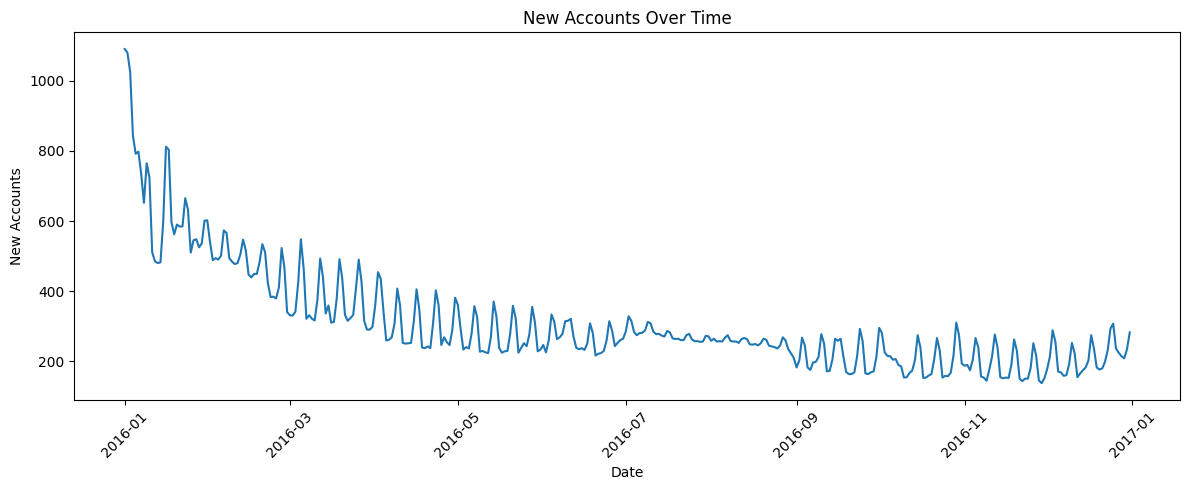

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    daily_accounts["created_date"],
    daily_accounts["new_accounts"]
)

plt.title("New Accounts Over Time")
plt.xlabel("Date")
plt.ylabel("New Accounts")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
account["created_month"] =account['created_time'].dt.to_period("M")

monthly_accounts =  account.groupby('created_month').size().reset_index(name="new_accounts")
monthly_accounts["created_month"] = monthly_accounts["created_month"].astype(str)
monthly_accounts


,created_month,new_accounts
0,2016-01,20760
1,2016-02,13776
2,2016-03,11478
3,2016-04,9232
4,2016-05,8433
5,2016-06,7953
6,2016-07,8598
7,2016-08,7809
8,2016-09,6237
9,2016-10,6331


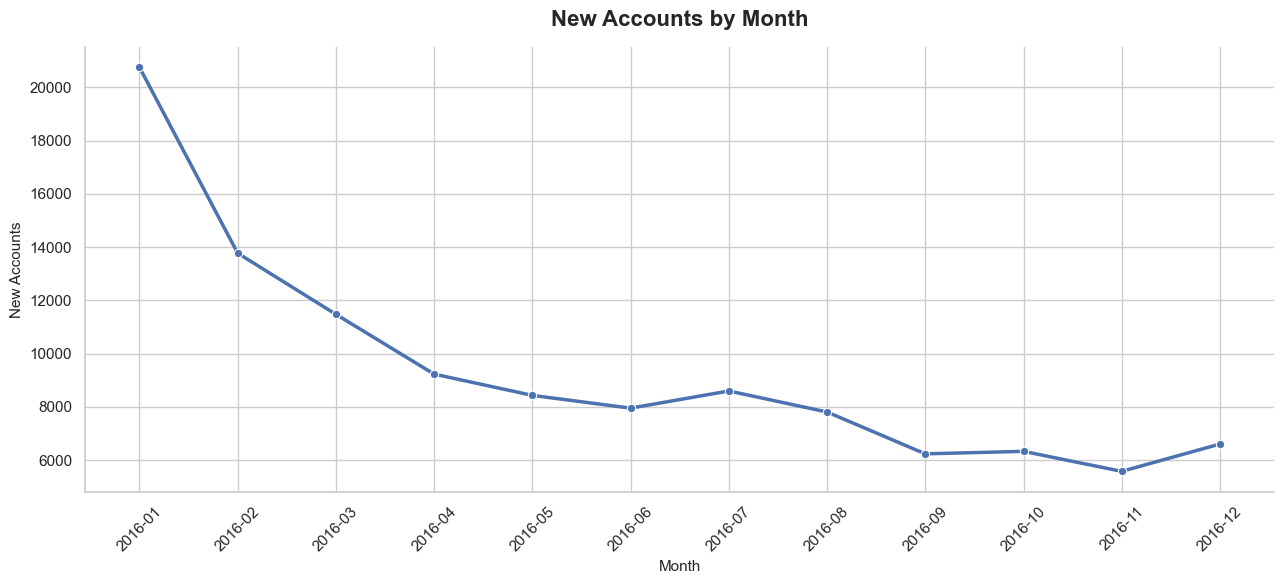

In [19]:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=monthly_accounts,
    x="created_month",
    y="new_accounts",
    marker="o",
    linewidth=2.5
)

plt.title(
    "New Accounts by Month",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month", fontsize=11)
plt.ylabel("New Accounts", fontsize=11)

plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()
plt.show()

In [20]:
platform_counts = account['created_platform'].value_counts()
platform_counts

created_platform
Android    92253
iOS        20539
Name: count, dtype: int64

C:\Users\Kimia\AppData\Local\Temp\ipykernel_2480\3333720962.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


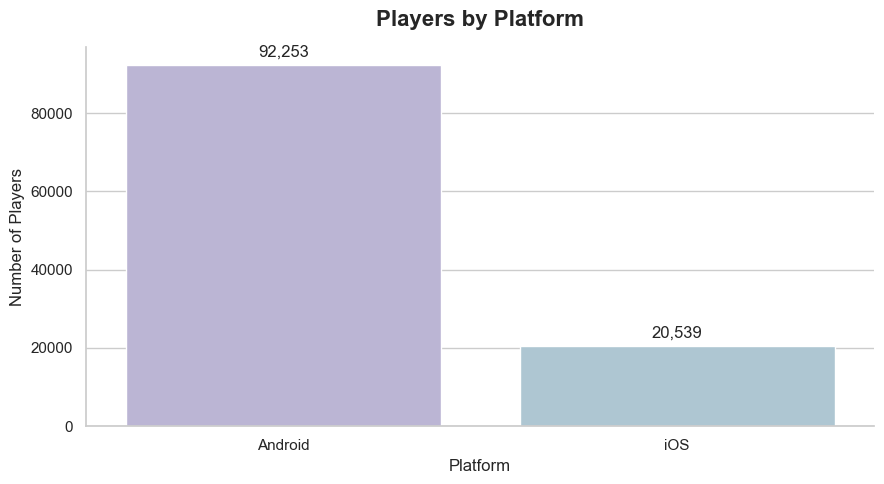

In [21]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=platform_counts.index,
    y=platform_counts.values,
    palette=["#B8B0D9", "#A8C8D8"]
)

plt.title(
    "Players by Platform",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Platform")
plt.ylabel("Number of Players")

sns.despine()

for container in ax.containers:
    labels = [f"{int(v):,}" for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        padding=4
    )

plt.tight_layout()
plt.show()

Why Analyze Device Types?

Understanding the distribution of device types helps us identify the most common hardware used by players. This is useful for understanding the player base and can provide context for later analyses of engagement, retention, and monetization across different devices.

In [22]:
device_counts = account["created_device"].value_counts()

top_devices = (
    account["created_device"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_devices.columns = ["device", "players"]

top_devices["percentage"] = (
    top_devices["players"] / len(account) * 100
)

top_devices

,device,players,percentage
0,"iPhone7,2",2764,2.450528
1,"iPhone8,1",2206,1.955812
2,"iPhone6,2",1456,1.290872
3,"iPhone4,1",1182,1.047947
4,"iPhone7,1",1122,0.994751
5,"iPhone8,2",1059,0.938896
6,"iPhone5,2",892,0.790836
7,"iPad4,4",880,0.780197
8,"iPad2,5",861,0.763352
9,"iPhone6,1",832,0.737641


C:\Users\Kimia\AppData\Local\Temp\ipykernel_2480\2273711542.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


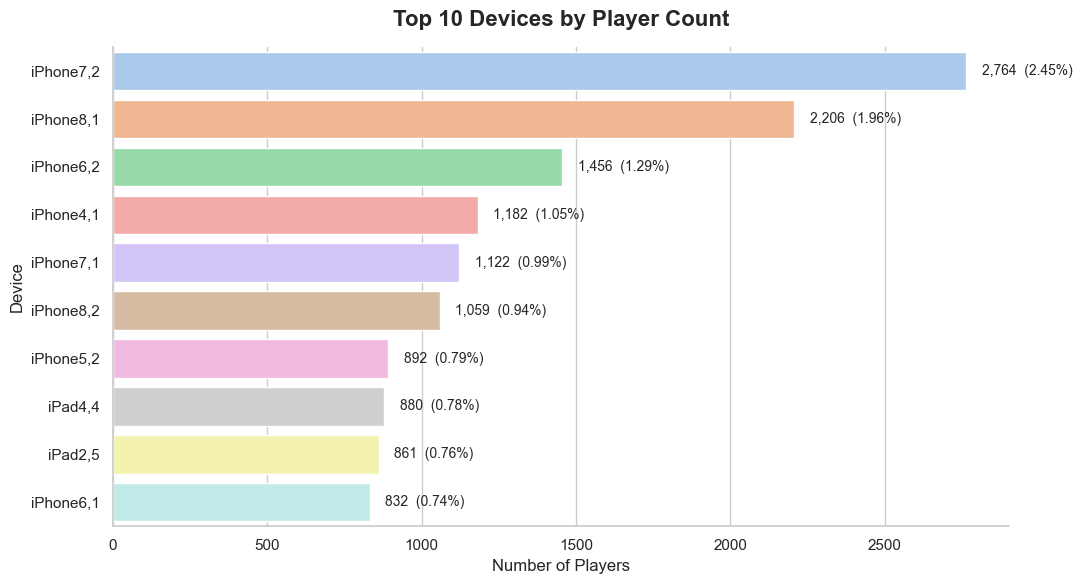

In [23]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=top_devices,
    x="players",
    y="device",
    palette="pastel"
)

plt.title(
    "Top 10 Devices by Player Count",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Players")
plt.ylabel("Device")

for i, row in top_devices.iterrows():
    ax.text(
        row["players"] + 50,
        i,
        f'{row["players"]:,}  ({row["percentage"]:.2f}%)',
        va="center",
        fontsize=10
    )

sns.despine()

plt.tight_layout()
plt.show()

DAU = Daily Active Users

In [24]:
daily_active_players = (sessions.groupby("date")["account_id"]).nunique().reset_index(name="active_players")
daily_active_players.head()

,date,active_players
0,2016-01-01,1083
1,2016-01-02,1558
2,2016-01-03,1872
3,2016-01-04,1884
4,2016-01-05,2068


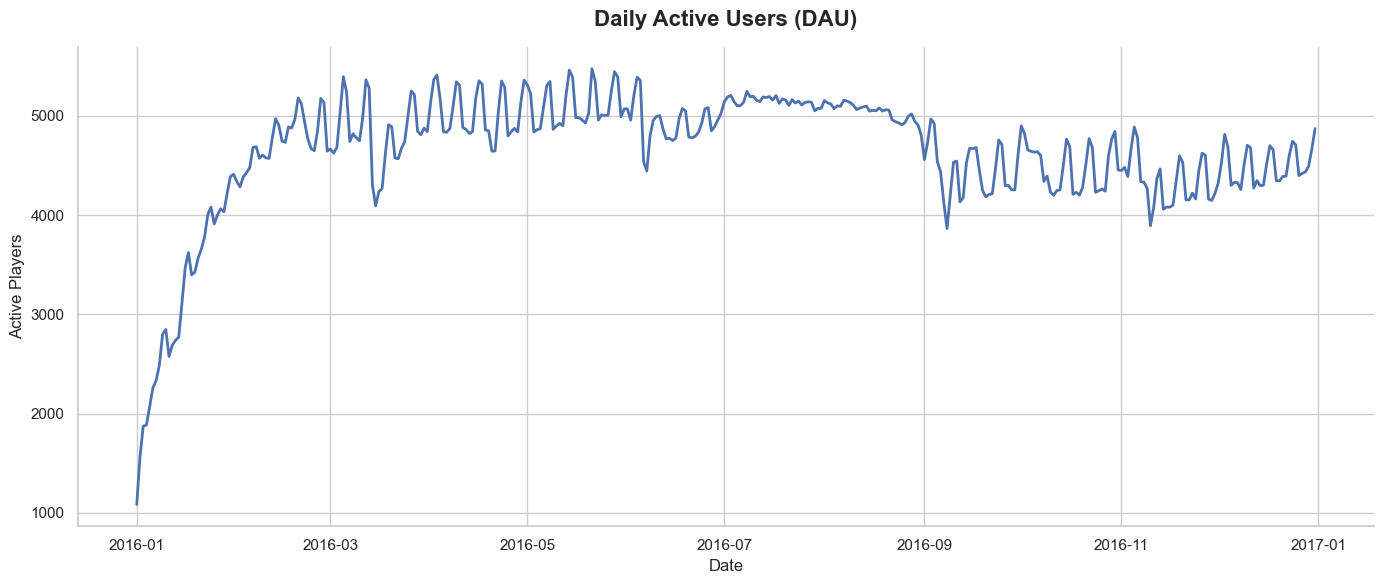

In [25]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_active_players,
    x="date",
    y="active_players",
    linewidth=2
)

plt.title(
    "Daily Active Users (DAU)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Date")
plt.ylabel("Active Players")

sns.despine()

plt.tight_layout()
plt.show()

In [26]:
sessions["session_count"].describe()

count    1.698974e+06
mean     3.587891e+00
std      3.671223e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      2.630000e+02
Name: session_count, dtype: float64

How are daily session counts distributed among player-days?

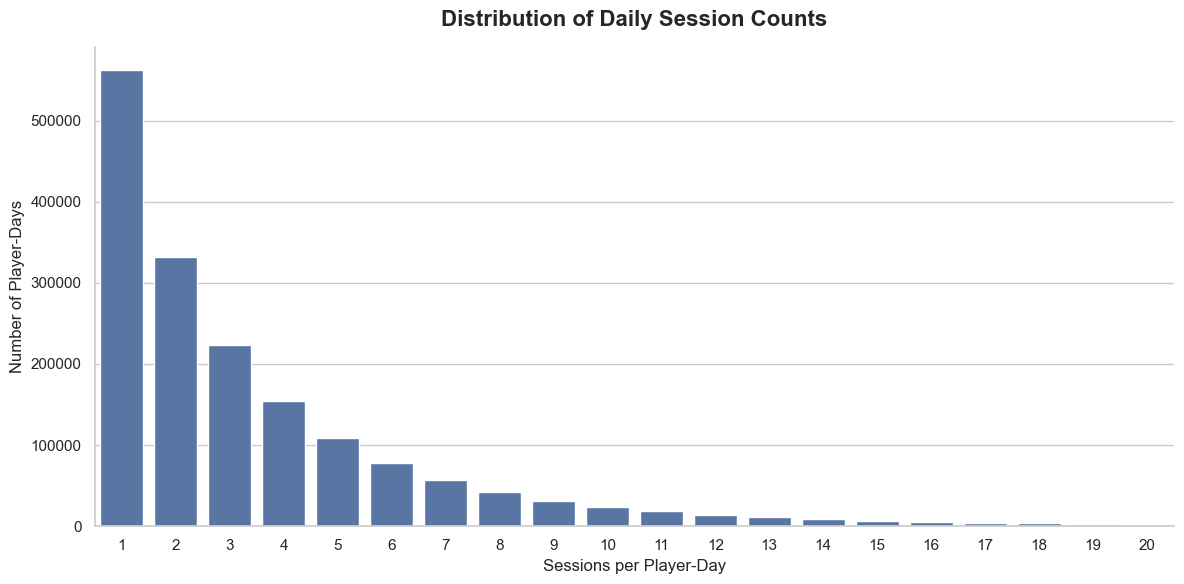

In [27]:
session_distribution = (
    sessions["session_count"]
    .value_counts()
    .sort_index()
)

session_distribution = session_distribution[
    session_distribution.index <= 20
]

plt.figure(figsize=(12, 6))

sns.barplot(
    x=session_distribution.index,
    y=session_distribution.values
)

plt.title(
    "Distribution of Daily Session Counts",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sessions per Player-Day")
plt.ylabel("Number of Player-Days")

sns.despine()
plt.tight_layout()
plt.show()

In [28]:
sessions["session_duration_sec"].describe()

count    1.698974e+06
mean     1.434244e+03
std      1.715709e+03
min      1.000000e+00
25%      3.490000e+02
50%      8.660000e+02
75%      1.867000e+03
max      5.705000e+04
Name: session_duration_sec, dtype: float64

Mean = 23.9 min > Median = 14.4 min  ------> right-skewed

In [29]:
sessions['session_duration_min'] = (sessions["session_duration_sec"]/60)

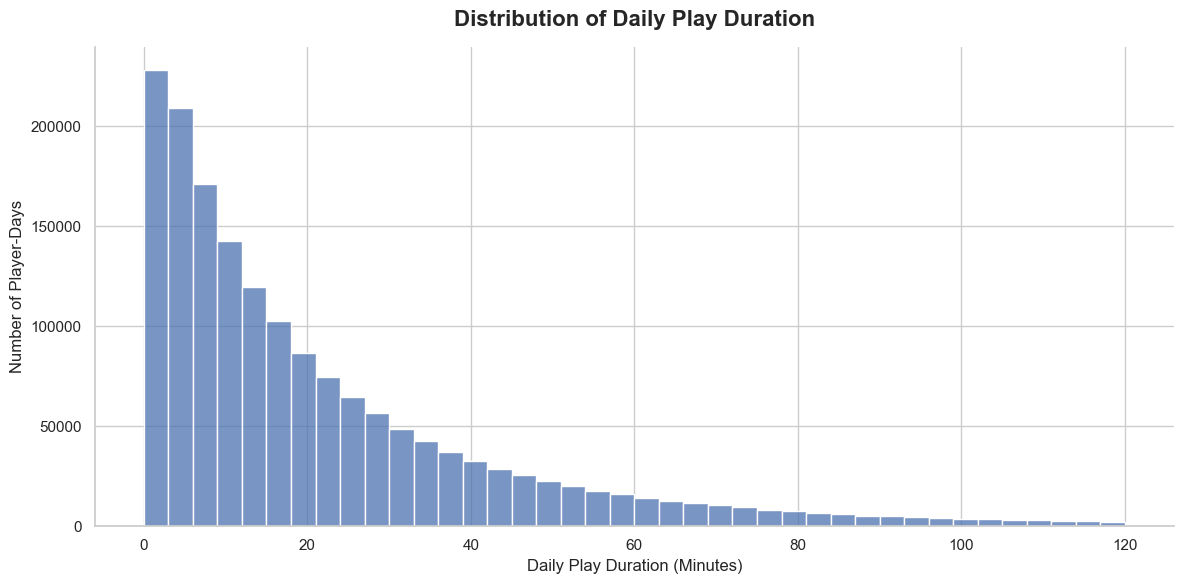

In [30]:
duration_distribution = sessions[
    sessions["session_duration_min"] <= 120
]

plt.figure(figsize=(12, 6))

sns.histplot(
    data=duration_distribution,
    x="session_duration_min",
    bins=40
)

plt.title(
    "Distribution of Daily Play Duration",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Daily Play Duration (Minutes)")
plt.ylabel("Number of Player-Days")

sns.despine()
plt.tight_layout()
plt.show()

Do players who have more sessions per day also spend more time playing?

In [31]:
avg_duration_by_sessions = (
    sessions
    .groupby("session_count")["session_duration_min"]
    .mean()
    .reset_index()
)

avg_duration_by_sessions = avg_duration_by_sessions[
    avg_duration_by_sessions["session_count"] <= 20
]

avg_duration_by_sessions.head(10)

,session_count,session_duration_min
0,1,5.756174
1,2,13.512404
2,3,20.871138
3,4,28.110025
4,5,34.988645
5,6,41.664962
6,7,47.990220
7,8,54.696833
8,9,61.417419
9,10,67.613180


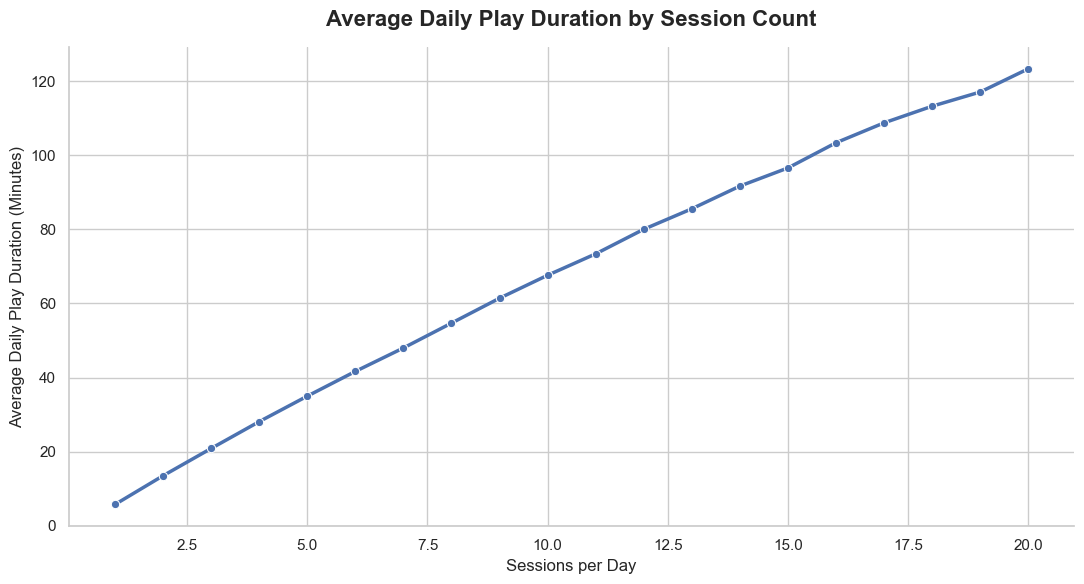

In [32]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=avg_duration_by_sessions,
    x="session_count",
    y="session_duration_min",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Average Daily Play Duration by Session Count",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sessions per Day")
plt.ylabel("Average Daily Play Duration (Minutes)")

sns.despine()
plt.tight_layout()
plt.show()

As the number of daily sessions increases, average daily play duration also increases.

### Daily Active Users (DAU)

The number of daily active players generally increased over time. Although there were some fluctuations across different periods, the overall trend was upward.

### Session Count

Most player-days had a relatively small number of sessions. The distribution was strongly right-skewed, meaning that while most player-days had only a few sessions, a small number had substantially more sessions.

### Session Duration

Most player-days had relatively short daily play durations. The distribution was also strongly right-skewed, with a small number of player-days showing unusually long play durations.

### Session Count vs. Duration

There was a positive relationship between the number of daily sessions and average daily play duration. As the number of sessions increased, the average amount of time spent playing also increased. This indicates that players with more daily sessions generally spent more time playing.


Do players come back after they first start playing the game?

In [33]:
first_session_date = (
    sessions
    .groupby("account_id")["date"]
    .min()
    .reset_index(name = "first_session_date")
    )
first_session_date.head()

,account_id,first_session_date
0,12314866,2016-01-01
1,12315420,2016-01-01
2,12315974,2016-01-01
3,12316528,2016-01-01
4,12317082,2016-01-01


In [34]:
retention_check = first_session_date.merge(
    account[["account_id", "created_date"]],
    on="account_id",
    how="left"
)

retention_check["date_match"] = (
    retention_check["first_session_date"] == retention_check["created_date"]

)

In [35]:

retention_check.head()

,account_id,first_session_date,created_date,date_match
0,12314866,2016-01-01,2016-01-01,True
1,12315420,2016-01-01,2016-01-01,True
2,12315974,2016-01-01,2016-01-01,True
3,12316528,2016-01-01,2016-01-01,True
4,12317082,2016-01-01,2016-01-01,True


In [36]:
retention_check['date_match'].value_counts()

date_match
True     112010
False       441
Name: count, dtype: int64

In [37]:
retention_check["first_session_date"] = pd.to_datetime(
    retention_check["first_session_date"]
)

retention_check["created_date"] = pd.to_datetime(
    retention_check["created_date"]
)

In [38]:
retention_check["days_difference"] = (
    retention_check["first_session_date"]
    - retention_check["created_date"]
).dt.days

In [39]:
retention_check["days_difference"].value_counts().sort_index()

days_difference
0      112010
1         421
2           6
3           3
4           1
7           2
11          1
16          1
26          1
31          1
33          1
35          1
148         1
229         1
Name: count, dtype: int64

Do players come back the day after they first start playing?

Day 0 = created_date

Day 1 = created_date + 1 day


Retention Window

In [40]:
data_end_date = sessions["date"].max()

In [41]:
retention_check["day_1_possible"] = (
    retention_check["created_date"] + pd.Timedelta(days=1)
    <= data_end_date
)

retention_check["day_1_possible"].value_counts()

day_1_possible
True     112171
False       280
Name: count, dtype: int64

Of the players who had the opportunity to return one day after account creation, how many actually came back?

In [42]:
retention_check["day_1_date"] = (
    retention_check["created_date"] + pd.Timedelta(days=1)
)

In [43]:
retention_check[["account_id", "created_date", "day_1_date", "day_1_possible"]].head()

,account_id,created_date,day_1_date,day_1_possible
0,12314866,2016-01-01,2016-01-02,True
1,12315420,2016-01-01,2016-01-02,True
2,12315974,2016-01-01,2016-01-02,True
3,12316528,2016-01-01,2016-01-02,True
4,12317082,2016-01-01,2016-01-02,True


In [44]:
active_dates = sessions[["account_id", "date"]].drop_duplicates()

In [45]:
active_dates.head()

,account_id,date
0,68730811144,2016-01-01
1,68730812806,2016-01-01
2,68730829426,2016-01-01
3,68730829426,2016-01-02
4,68730829426,2016-01-03


In [46]:
retention_check = retention_check.merge(
    active_dates,
    left_on=["account_id", "day_1_date"],
    right_on=["account_id", "date"],
    how="left"
)

In [47]:
retention_check["day_1_retained"] = (
    retention_check["date"].notna()
)

In [48]:
retention_check["day_1_retained"].value_counts()

day_1_retained
False    67888
True     44563
Name: count, dtype: int64

In [49]:
day_1_cohort = retention_check[
    retention_check["day_1_possible"]
].copy()

In [50]:
day_1_cohort["day_1_retained"].value_counts()

day_1_retained
False    67608
True     44563
Name: count, dtype: int64

Day 1 Retention
=
Players who returned on Day 1
÷
Players who had the opportunity to return
× 100

In [51]:
day_1_retention = (
    day_1_cohort["day_1_retained"].mean() * 100
)

day_1_retention

np.float64(39.727737115653774)

created_date → Day 0


created_date + 7 days → Day 7

In [52]:
retention_check["day_7_date"] = (
    retention_check["created_date"] + pd.Timedelta(days=7)
)

In [53]:
retention_check["day_7_possible"] = (
    retention_check["day_7_date"] <= data_end_date
)

In [54]:
retention_check["day_7_possible"].value_counts()

day_7_possible
True     110750
False      1701
Name: count, dtype: int64

In [55]:
retention_check = retention_check.merge(
    active_dates,
    left_on=["account_id", "day_7_date"],
    right_on=["account_id", "date"],
    how="left"
)

In [56]:
active_dates_set = set(
    zip(
        active_dates["account_id"],
        active_dates["date"]
    )
)

In [57]:
retention_check["day_7_retained"] = (
    retention_check.apply(
        lambda row:
        (row["account_id"], row["day_7_date"]) in active_dates_set,
        axis=1
    )
)

In [58]:
day_7_cohort = retention_check[
    retention_check["day_7_possible"]
].copy()

In [59]:
day_7_cohort["day_7_retained"].value_counts()

day_7_retained
False    88540
True     22210
Name: count, dtype: int64

In [60]:
day_7_retention = (
    day_7_cohort["day_7_retained"].mean() * 100
)

day_7_retention

np.float64(20.054176072234764)

In [61]:
retention_summary = pd.DataFrame({
    "Retention Period": ["Day 1", "Day 7"],
    "Retention": [day_1_retention, day_7_retention]
})

retention_summary

,Retention Period,Retention
0,Day 1,39.727737
1,Day 7,20.054176


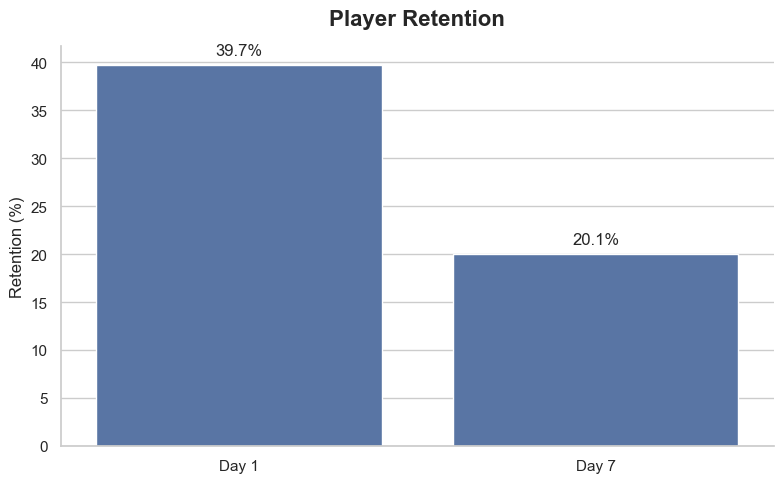

In [62]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=retention_summary,
    x="Retention Period",
    y="Retention"
)

plt.title(
    "Player Retention",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("")
plt.ylabel("Retention (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5
    )

sns.despine()
plt.tight_layout()
plt.show()

🔥 Cohort Retention

In [63]:
account["cohort_month"] = (
    account["created_time"]
    .dt.to_period("M")
)

In [64]:
account[["account_id", "created_time", "cohort_month"]].head()

,account_id,created_time,cohort_month
0,13514010,2016-03-02 17:11:00.332,2016-03
1,4308483975,2016-03-02 20:57:46.140,2016-03
2,17193137415,2016-03-02 13:52:16.735,2016-03
3,21488104920,2016-03-02 12:43:27.899,2016-03
4,21488107995,2016-03-02 17:20:12.145,2016-03


In [65]:
cohort_size = (
    account
    .groupby("cohort_month")["account_id"]
    .nunique()
    .reset_index(name="players")
)

cohort_size

,cohort_month,players
0,2016-01,20760
1,2016-02,13776
2,2016-03,11478
3,2016-04,9232
4,2016-05,8433
5,2016-06,7953
6,2016-07,8598
7,2016-08,7809
8,2016-09,6237
9,2016-10,6331


In [66]:
day_1_cohort["cohort_month"] = (
    day_1_cohort["created_date"]
    .dt.to_period("M")
)

In [67]:
cohort_d1 = (
    day_1_cohort
    .groupby("cohort_month")["day_1_retained"]
    .mean()
    .mul(100)
    .reset_index(name="d1_retention")
)

cohort_d1

,cohort_month,d1_retention
0,2016-01,42.707225
1,2016-02,40.591535
2,2016-03,37.518541
3,2016-04,38.284335
4,2016-05,38.702381
5,2016-06,37.463795
6,2016-07,40.663176
7,2016-08,40.578968
8,2016-09,38.290022
9,2016-10,38.124605


In [68]:
day_7_cohort["cohort_month"] = (
    day_7_cohort["created_date"]
    .dt.to_period("M")
)

cohort_d7 = (
    day_7_cohort
    .groupby("cohort_month")["day_7_retained"]
    .mean()
    .mul(100)
    .reset_index(name="d7_retention")
)

In [69]:
cohort_retention = cohort_d1.merge(
    cohort_d7,
    on="cohort_month",
    how="inner"
)

cohort_retention

,cohort_month,d1_retention,d7_retention
0,2016-01,42.707225,23.362994
1,2016-02,40.591535,20.033511
2,2016-03,37.518541,19.649245
3,2016-04,38.284335,19.537078
4,2016-05,38.702381,20.214286
5,2016-06,37.463795,18.058179
6,2016-07,40.663176,19.080861
7,2016-08,40.578968,18.163187
8,2016-09,38.290022,18.543471
9,2016-10,38.124605,18.611638


In [70]:
retention_check["day_14_date"] = (
    retention_check["created_date"] + pd.Timedelta(days=14)
)

retention_check["day_30_date"] = (
    retention_check["created_date"] + pd.Timedelta(days=30)
)




In [71]:
retention_check["day_14_possible"] = (
    retention_check["day_14_date"] <= data_end_date
)

retention_check["day_30_possible"] = (
    retention_check["day_30_date"] <= data_end_date
)




In [72]:
retention_check["day_14_retained"] = (
    retention_check.apply(
        lambda row: (
            row["account_id"],
            row["day_14_date"]
        ) in active_dates_set,
        axis=1
    )
)

retention_check["day_30_retained"] = (
    retention_check.apply(
        lambda row: (
            row["account_id"],
            row["day_30_date"]
        ) in active_dates_set,
        axis=1
    )
)

In [73]:
day_14_cohort = retention_check[
    retention_check["day_14_possible"]
].copy()

day_30_cohort = retention_check[
    retention_check["day_30_possible"]
].copy()

In [74]:
day_14_cohort["cohort_month"] = (
    day_14_cohort["created_date"].dt.to_period("M")
)

day_30_cohort["cohort_month"] = (
    day_30_cohort["created_date"].dt.to_period("M")
)

In [75]:
cohort_d14 = (
    day_14_cohort
    .groupby("cohort_month")["day_14_retained"]
    .mean()
    .mul(100)
    .reset_index(name="d14_retention")
)

cohort_d30 = (
    day_30_cohort
    .groupby("cohort_month")["day_30_retained"]
    .mean()
    .mul(100)
    .reset_index(name="d30_retention")
)





In [76]:
cohort_retention = (
    cohort_retention
    .merge(cohort_d14, on="cohort_month", how="left")
    .merge(cohort_d30, on="cohort_month", how="left")
)

cohort_retention

,cohort_month,d1_retention,d7_retention,d14_retention,d30_retention
0,2016-01,42.707225,23.362994,18.294806,13.318503
1,2016-02,40.591535,20.033511,15.174474,10.155169
2,2016-03,37.518541,19.649245,14.920164,10.906553
3,2016-04,38.284335,19.537078,15.434401,11.068451
4,2016-05,38.702381,20.214286,14.869048,10.059524
5,2016-06,37.463795,18.058179,13.826974,9.897998
6,2016-07,40.663176,19.080861,14.426992,9.400814
7,2016-08,40.578968,18.163187,12.834636,8.082490
8,2016-09,38.290022,18.543471,14.116137,9.592557
9,2016-10,38.124605,18.611638,14.104997,9.013283


In [77]:
cohort_heatmap = cohort_retention.copy()

cohort_heatmap["cohort_month"] = (
    cohort_heatmap["cohort_month"].astype(str)
)

cohort_heatmap = cohort_heatmap.set_index("cohort_month")

cohort_heatmap

,d1_retention,d7_retention,d14_retention,d30_retention
cohort_month,,,,
2016-01,42.707225,23.362994,18.294806,13.318503
2016-02,40.591535,20.033511,15.174474,10.155169
2016-03,37.518541,19.649245,14.920164,10.906553
2016-04,38.284335,19.537078,15.434401,11.068451
2016-05,38.702381,20.214286,14.869048,10.059524
2016-06,37.463795,18.058179,13.826974,9.897998
2016-07,40.663176,19.080861,14.426992,9.400814
2016-08,40.578968,18.163187,12.834636,8.082490
2016-09,38.290022,18.543471,14.116137,9.592557


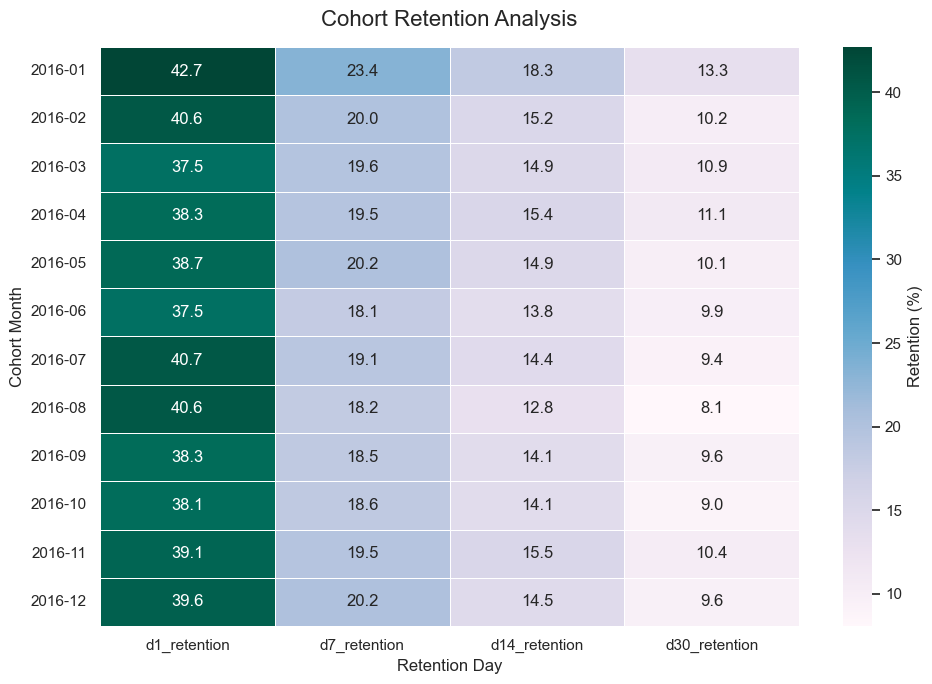

In [78]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    cohort_heatmap[
        ["d1_retention", "d7_retention", "d14_retention", "d30_retention"]
    ],
    annot=True,
    fmt=".1f",
    cmap="PuBuGn",
    linewidths=0.5,
    cbar_kws={"label": "Retention (%)"}
)

plt.title("Cohort Retention Analysis", fontsize=16, pad=15)
plt.xlabel("Retention Day")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()

🎯 Business Challenge

Do highly engaged players have better retention?

Are players who have more sessions on their first day more likely to return on Day 1 and Day 7?

In [79]:
day_0 = (
    sessions
    .sort_values("date")
    .groupby("account_id")
    .first()
    .reset_index()
)

day_0 = day_0[
    ["account_id", "date", "session_count", "session_duration_sec"]
]

day_0.head()

,account_id,date,session_count,session_duration_sec
0,12314866,2016-01-01,7,3171
1,12315420,2016-01-01,19,14249
2,12315974,2016-01-01,1,151
3,12316528,2016-01-01,6,3770
4,12317082,2016-01-01,1,234


In [80]:
day_0["engagement_group"] = pd.cut(
    day_0["session_count"],
    bins=[0, 1, 2, 4, float("inf")],
    labels=["1 session", "2 sessions", "3–4 sessions", "5+ sessions"]
)

day_0["engagement_group"].value_counts().sort_index()

engagement_group
1 session       65389
2 sessions      18376
3–4 sessions    14510
5+ sessions     14176
Name: count, dtype: int64

Business Challenge

Does Day-0 engagement relate to Day-1 and Day-7 retention?

In [81]:
engagement_retention = day_0[
    ["account_id", "engagement_group"]
].merge(
    retention_check[
        ["account_id", "day_1_possible", "day_1_retained",
         "day_7_possible", "day_7_retained"]
    ],
    on="account_id",
    how="left"
)

engagement_retention.head()

,account_id,engagement_group,day_1_possible,day_1_retained,day_7_possible,day_7_retained
0,12314866,5+ sessions,True,False,True,False
1,12315420,5+ sessions,True,True,True,False
2,12315974,1 session,True,False,True,False
3,12316528,5+ sessions,True,True,True,True
4,12317082,1 session,True,False,True,False


In [82]:
d1_summary = (
    engagement_retention[
        engagement_retention["day_1_possible"]
    ]
    .groupby("engagement_group", observed=True)
    .agg(
        d1_players=("account_id", "nunique"),
        d1_retained=("day_1_retained", "sum")
    )
    .reset_index()
)

d1_summary["d1_retention"] = (
    d1_summary["d1_retained"]
    / d1_summary["d1_players"]
    * 100
)


d7_summary = (
    engagement_retention[
        engagement_retention["day_7_possible"]
    ]
    .groupby("engagement_group", observed=True)
    .agg(
        d7_players=("account_id", "nunique"),
        d7_retained=("day_7_retained", "sum")
    )
    .reset_index()
)

d7_summary["d7_retention"] = (
    d7_summary["d7_retained"]
    / d7_summary["d7_players"]
    * 100
)


engagement_retention_summary = (
    d1_summary[
        ["engagement_group", "d1_players", "d1_retention"]
    ]
    .merge(
        d7_summary[
            ["engagement_group", "d7_players", "d7_retention"]
        ],
        on="engagement_group",
        how="outer"
    )
)

engagement_retention_summary

,engagement_group,d1_players,d1_retention,d7_players,d7_retention
0,1 session,65227,20.313674,64407,8.117130
1,2 sessions,18323,49.937237,18061,22.689774
2,3–4 sessions,14471,68.806579,14289,35.971727
3,5+ sessions,14150,86.261484,13993,55.341957


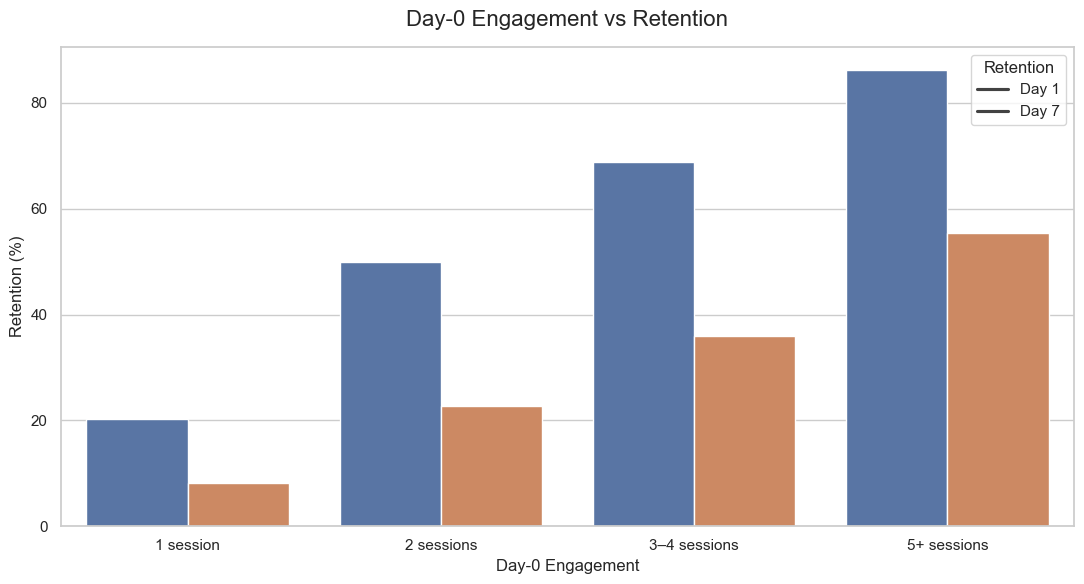

In [83]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=engagement_retention_summary.melt(
        id_vars="engagement_group",
        value_vars=["d1_retention", "d7_retention"],
        var_name="retention_day",
        value_name="retention"
    ),
    x="engagement_group",
    y="retention",
    hue="retention_day"
)

plt.title("Day-0 Engagement vs Retention", fontsize=16, pad=15)
plt.xlabel("Day-0 Engagement")
plt.ylabel("Retention (%)")

plt.legend(
    title="Retention",
    labels=["Day 1", "Day 7"]
)

plt.tight_layout()
plt.show()

💰 Next Business Challenge

Are more engaged players also more likely to spend money?

In [85]:
player_monetization = (
    iap_purchase
    .groupby("account_id")
    .agg(
        purchase_count=("account_id", "size"),
        total_revenue_usd=("iap_price_usd_cents", "sum")
    )
    .reset_index()
)

player_monetization["total_revenue_usd"] = (
    player_monetization["total_revenue_usd"] / 100
)

player_monetization.head()

,account_id,purchase_count,total_revenue_usd
0,12322622,5,3.28
1,12336472,23,181.07
2,12348106,5,11.05
3,12352080,1,1.84
4,12365400,11,17.28


Are more engaged players more likely to spend money?

In [86]:
engagement_monetization = day_0[
    ["account_id", "engagement_group"]
].merge(
    player_monetization,
    on="account_id",
    how="left"
)

engagement_monetization["purchase_count"] = (
    engagement_monetization["purchase_count"]
    .fillna(0)
)

engagement_monetization["total_revenue_usd"] = (
    engagement_monetization["total_revenue_usd"]
    .fillna(0)
)

engagement_monetization["is_payer"] = (
    engagement_monetization["purchase_count"] > 0
)

engagement_monetization.head()

,account_id,engagement_group,purchase_count,total_revenue_usd,is_payer
0,12314866,5+ sessions,0.0,0.0,False
1,12315420,5+ sessions,0.0,0.0,False
2,12315974,1 session,0.0,0.0,False
3,12316528,5+ sessions,0.0,0.0,False
4,12317082,1 session,0.0,0.0,False


Business Challenge

Are more engaged players more likely to spend money?

In [87]:
monetization_summary = (
    engagement_monetization
    .groupby("engagement_group", observed=True)
    .agg(
        players=("account_id", "nunique"),
        paying_players=("is_payer", "sum"),
        revenue=("total_revenue_usd", "sum")
    )
    .reset_index()
)

monetization_summary["payer_conversion"] = (
    monetization_summary["paying_players"]
    / monetization_summary["players"]
    * 100
)

monetization_summary

,engagement_group,players,paying_players,revenue,payer_conversion
0,1 session,65389,310,10020.69,0.474086
1,2 sessions,18376,228,5710.60,1.240749
2,3–4 sessions,14510,325,8546.74,2.239835
3,5+ sessions,14176,686,18240.59,4.839165


Higher Day-0 engagement is associated with higher payer conversion. Players with 5+ sessions on their first active day had a payer conversion rate of 4.84%, compared with 0.47% among players with only one session.

Players who engage more during their first day may represent a higher-value player segment. Understanding what drives early engagement could help inform onboarding, progression, and early monetization strategies.

Do more engaged players also generate more revenue per player?

ARPU = Total Revenue ÷ Total Players

In [88]:
monetization_summary["ARPU"] = (
    monetization_summary["revenue"]
    / monetization_summary["players"]
)

monetization_summary

,engagement_group,players,paying_players,revenue,payer_conversion,ARPU
0,1 session,65389,310,10020.69,0.474086,0.153247
1,2 sessions,18376,228,5710.60,1.240749,0.310764
2,3–4 sessions,14510,325,8546.74,2.239835,0.589024
3,5+ sessions,14176,686,18240.59,4.839165,1.286723


ARPPU = Total Revenue ÷ Paying Players

In [89]:
monetization_summary["ARPPU"] = (
    monetization_summary["revenue"]
    / monetization_summary["paying_players"]
)

monetization_summary

,engagement_group,players,paying_players,revenue,payer_conversion,ARPU,ARPPU
0,1 session,65389,310,10020.69,0.474086,0.153247,32.324806
1,2 sessions,18376,228,5710.60,1.240749,0.310764,25.046491
2,3–4 sessions,14510,325,8546.74,2.239835,0.589024,26.297662
3,5+ sessions,14176,686,18240.59,4.839165,1.286723,26.589781


Higher Day-0 engagement is associated with higher payer conversion and revenue per player, while average revenue per paying player remains relatively stable across engagement groups.

This suggests that improving early engagement may be worth investigating as a potential lever for increasing the number of players who eventually monetize.


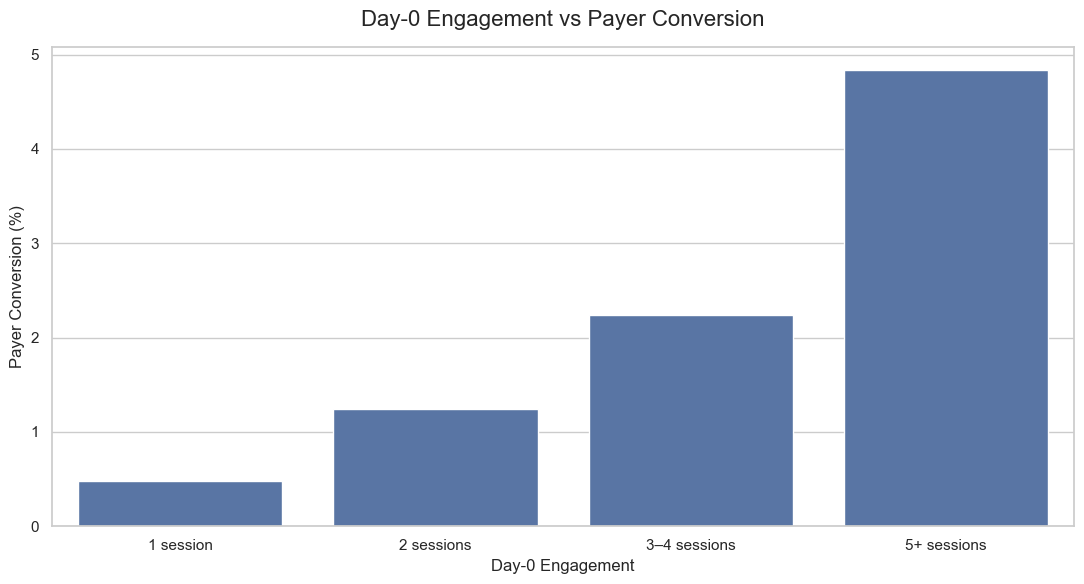

In [90]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=monetization_summary,
    x="engagement_group",
    y="payer_conversion"
)

plt.title(
    "Day-0 Engagement vs Payer Conversion",
    fontsize=16,
    pad=15
)

plt.xlabel("Day-0 Engagement")
plt.ylabel("Payer Conversion (%)")

plt.tight_layout()
plt.show()

Player Segmentation 🎮

Who are our most valuable player segments?

Engagement → Retention → Monetization

-----------------------

Engagement
→ Session count

Retention
→ D1 / D7

Monetization
→ Revenue / Payer

--------------------------------------

Step1: Player Metric :

day_0_sessions

day_0_duration

D1 Retention

D7 Retention

Total Revenue

Is Payer

In [91]:
player_features = (
    day_0[
        ["account_id", "session_count", "session_duration_sec"]
    ]
    .rename(
        columns={
            "session_count": "day_0_sessions",
            "session_duration_sec": "day_0_duration_sec"
        }
    )
    .merge(
        retention_check[
            ["account_id", "day_1_possible", "day_1_retained",
             "day_7_possible", "day_7_retained"]
        ],
        on="account_id",
        how="left"
    )
    .merge(
        player_monetization[
            ["account_id", "purchase_count", "total_revenue_usd"]
        ],
        on="account_id",
        how="left"
    )
)

player_features["purchase_count"] = (
    player_features["purchase_count"].fillna(0)
)

player_features["total_revenue_usd"] = (
    player_features["total_revenue_usd"].fillna(0)
)

player_features["is_payer"] = (
    player_features["purchase_count"] > 0
)

player_features.head()

,account_id,day_0_sessions,day_0_duration_sec,day_1_possible,day_1_retained,day_7_possible,day_7_retained,purchase_count,total_revenue_usd,is_payer
0,12314866,7,3171,True,False,True,False,0.0,0.0,False
1,12315420,19,14249,True,True,True,False,0.0,0.0,False
2,12315974,1,151,True,False,True,False,0.0,0.0,False
3,12316528,6,3770,True,True,True,True,0.0,0.0,False
4,12317082,1,234,True,False,True,False,0.0,0.0,False


### Step 2 — Building Behavioral Segments 🎮

1. **Low Engagement** → Only 1 session on Day 0
2. **Moderate Engagement** → 2 sessions
3. **High Engagement** → 3–4 sessions
4. **Very High Engagement** → 5+ sessions


In [92]:
player_features["engagement_segment"] = pd.cut(
    player_features["day_0_sessions"],
    bins=[0, 1, 2, 4, float("inf")],
    labels=[
        "Low Engagement",
        "Moderate Engagement",
        "High Engagement",
        "Very High Engagement"
    ]
)

player_features[
    [
        "account_id",
        "engagement_segment",
        "day_0_sessions",
        "day_1_retained",
        "day_7_retained",
        "is_payer",
        "total_revenue_usd"
    ]
].head()

,account_id,engagement_segment,day_0_sessions,day_1_retained,day_7_retained,is_payer,total_revenue_usd
0,12314866,Very High Engagement,7,False,False,False,0.0
1,12315420,Very High Engagement,19,True,False,False,0.0
2,12315974,Low Engagement,1,False,False,False,0.0
3,12316528,Very High Engagement,6,True,True,False,0.0
4,12317082,Low Engagement,1,False,False,False,0.0


In [93]:
segment_summary = (
    player_features
    .groupby("engagement_segment", observed=True)
    .agg(
        players=("account_id", "nunique"),
        d1_retention=("day_1_retained", "mean"),
        d7_retention=("day_7_retained", "mean"),
        paying_players=("is_payer", "sum"),
        revenue=("total_revenue_usd", "sum")
    )
    .reset_index()
)

segment_summary["d1_retention"] *= 100
segment_summary["d7_retention"] *= 100

segment_summary["payer_conversion"] = (
    segment_summary["paying_players"]
    / segment_summary["players"]
    * 100
)

segment_summary["ARPU"] = (
    segment_summary["revenue"]
    / segment_summary["players"]
)

segment_summary

,engagement_segment,players,d1_retention,d7_retention,paying_players,revenue,payer_conversion,ARPU
0,Low Engagement,65389,20.263347,7.995229,310,10020.69,0.474086,0.153247
1,Moderate Engagement,18376,49.793209,22.300827,228,5710.60,1.240749,0.310764
2,High Engagement,14510,68.621640,35.423846,325,8546.74,2.239835,0.589024
3,Very High Engagement,14176,86.103273,54.627540,686,18240.59,4.839165,1.286723


In [94]:
segment_retention = (
    player_features[
        player_features["day_7_possible"]
    ]
    .groupby("engagement_segment", observed=True)
    .agg(
        players=("account_id", "nunique"),
        d7_retained=("day_7_retained", "sum")
    )
    .reset_index()
)

segment_retention["d7_retention"] = (
    segment_retention["d7_retained"]
    / segment_retention["players"]
    * 100
)

segment_retention

,engagement_segment,players,d7_retained,d7_retention
0,Low Engagement,64407,5228,8.117130
1,Moderate Engagement,18061,4098,22.689774
2,High Engagement,14289,5140,35.971727
3,Very High Engagement,13993,7744,55.341957


Higher Day-0 engagement is associated with substantially higher Day-7 retention.

Are retained players more likely to spend? 💰

Business Challenge

Are players who return on Day 7 more likely to spend money?

In [95]:
retention_monetization = player_features[
    player_features["day_7_possible"]
].copy()

retention_monetization["d7_status"] = np.where(
    retention_monetization["day_7_retained"],
    "D7 Retained",
    "Not Retained"
)

In [97]:
retention_monetization_summary = (
    retention_monetization
    .groupby("d7_status")
    .agg(
        players=("account_id", "nunique"),
        paying_players=("is_payer", "sum"),
        revenue=("total_revenue_usd", "sum")
    )
    .reset_index()
)

retention_monetization_summary["payer_conversion"] = (
    retention_monetization_summary["paying_players"]
    / retention_monetization_summary["players"]
    * 100
)

retention_monetization_summary["ARPU"] = (
    retention_monetization_summary["revenue"]
    / retention_monetization_summary["players"]
)

In [98]:
retention_monetization_summary

,d7_status,players,paying_players,revenue,payer_conversion,ARPU
0,D7 Retained,22210,1180,38225.53,5.312922,1.721095
1,Not Retained,88540,357,4191.73,0.403208,0.047343


Among players who paid, do D7-retained players spend more per payer?

In [99]:
retention_monetization_summary["ARPPU"] = (
    retention_monetization_summary["revenue"]
    / retention_monetization_summary["paying_players"]
)

In [100]:
retention_monetization_summary[
    ["d7_status", "payer_conversion", "ARPU", "ARPPU"]
]

,d7_status,payer_conversion,ARPU,ARPPU
0,D7 Retained,5.312922,1.721095,32.394517
1,Not Retained,0.403208,0.047343,11.741541


Payer Conversion:

5.31% vs. 0.40% → D7-retained players have a much higher payer conversion rate.

------------------------------------------------------------------------------------------

ARPU:

$1.72 vs. $0.05 → Revenue per player is substantially higher among the retained group.

--------------------------------------------------------------------------------------------

ARPPU:

$32.39 vs. $11.74 → Even among players who made a purchase, the average revenue per payer is higher in the retained group.

Business Insight

Players who were retained through Day 7 showed substantially higher monetization metrics, including payer conversion, ARPU, and ARPPU.

What player behaviors are associated with both stronger retention and higher monetization?

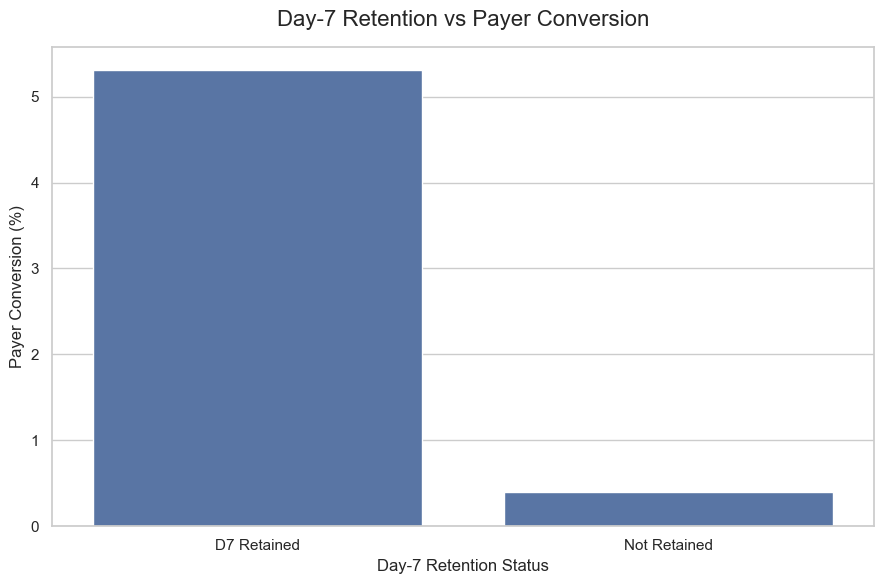

In [101]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=retention_monetization_summary,
    x="d7_status",
    y="payer_conversion"
)

plt.title(
    "Day-7 Retention vs Payer Conversion",
    fontsize=16,
    pad=15
)

plt.xlabel("Day-7 Retention Status")
plt.ylabel("Payer Conversion (%)")

plt.tight_layout()
plt.show()

📱 Platform Analysis

Business Challenge

How do Android and iOS players differ in engagement, retention, and monetization?

### Step 1 — Connecting Platform to Player Features 🎮


In [102]:
player_features = player_features.merge(
    account[
        ["account_id", "created_platform"]
    ],
    on="account_id",
    how="left"
)

In [103]:
player_features[
    ["account_id", "created_platform"]
].head()

,account_id,created_platform
0,12314866,Android
1,12315420,Android
2,12315974,Android
3,12316528,Android
4,12317082,Android


📱 Step 2 — Platform Engagement



Do Android and iOS players show different levels of early engagement?

In [104]:
platform_engagement = (
    player_features
    .groupby("created_platform")
    .agg(
        players=("account_id", "nunique"),
        avg_day_0_sessions=("day_0_sessions", "mean"),
        median_day_0_sessions=("day_0_sessions", "median")
    )
    .reset_index()
)

In [105]:
platform_engagement

,created_platform,players,avg_day_0_sessions,median_day_0_sessions
0,Android,92008,2.428354,1.0
1,iOS,20443,2.387565,1.0


⏱️ Step 3 — Day-0 Play Duration

In [106]:
platform_duration = (
    player_features
    .groupby("created_platform")
    .agg(
        players=("account_id", "nunique"),
        avg_day_0_duration_sec=("day_0_duration_sec", "mean"),
        median_day_0_duration_sec=("day_0_duration_sec", "median")
    )
    .reset_index()
)

platform_duration["avg_day_0_duration_min"] = (
    platform_duration["avg_day_0_duration_sec"] / 60
)

platform_duration["median_day_0_duration_min"] = (
    platform_duration["median_day_0_duration_sec"] / 60
)

In [107]:
platform_duration[
    [
        "created_platform",
        "players",
        "avg_day_0_duration_min",
        "median_day_0_duration_min"
    ]
]

,created_platform,players,avg_day_0_duration_min,median_day_0_duration_min
0,Android,92008,19.709851,8.216667
1,iOS,20443,16.942980,5.266667


Key Takeaways

Android players have a higher average session duration: 19.7 minutes vs. 16.9 minutes on iOS.

The median is also higher on Android: 8.2 minutes vs. 5.3 minutes.

Since the mean is considerably higher than the median, session duration remains right-skewed on both platforms.

Therefore, the median is more representative of the typical player’s session duration.

Android and iOS players show similar Day-0 session counts, but Android players have higher observed Day-0 play duration.

📈 Platform → Retention

In [108]:
platform_retention = (
    player_features
    .groupby("created_platform")
    .agg(
        d1_players=("day_1_possible", "sum"),
        d1_retained=("day_1_retained", "sum"),
        d7_players=("day_7_possible", "sum"),
        d7_retained=("day_7_retained", "sum")
    )
    .reset_index()
)

platform_retention["d1_retention"] = (
    platform_retention["d1_retained"]
    / platform_retention["d1_players"]
    * 100
)

platform_retention["d7_retention"] = (
    platform_retention["d7_retained"]
    / platform_retention["d7_players"]
    * 100
)

In [109]:
platform_retention[
    [
        "created_platform",
        "d1_players",
        "d1_retention",
        "d7_players",
        "d7_retention"
    ]
]

,created_platform,d1_players,d1_retention,d7_players,d7_retention
0,Android,91771,39.804513,90592,19.491787
1,iOS,20400,39.382353,20158,22.581605


Android players showed higher Day-0 play duration, while iOS players showed higher D7 retention

💰 Step 4 — Platform Monetization

In [110]:
platform_monetization = (
    player_features
    .groupby("created_platform")
    .agg(
        players=("account_id", "nunique"),
        paying_players=("is_payer", "sum"),
        revenue=("total_revenue_usd", "sum")
    )
    .reset_index()
)

platform_monetization["payer_conversion"] = (
    platform_monetization["paying_players"]
    / platform_monetization["players"]
    * 100
)

platform_monetization["ARPU"] = (
    platform_monetization["revenue"]
    / platform_monetization["players"]
)

platform_monetization["ARPPU"] = (
    platform_monetization["revenue"]
    / platform_monetization["paying_players"]
)

In [111]:
platform_monetization[
    [
        "created_platform",
        "players",
        "payer_conversion",
        "ARPU",
        "ARPPU"
    ]
]

,created_platform,players,payer_conversion,ARPU,ARPPU
0,Android,92008,1.250978,0.273706,21.879392
1,iOS,20443,1.946877,0.847989,43.556382


Payer Conversion:

iOS = 1.95% vs. Android = 1.25% → iOS players have a higher payer conversion rate.

----------------------------------------------------------------------------------------

ARPU:

iOS = $0.85 vs. Android = $0.27 → Revenue per player is higher on iOS.

--------------------------------------------------------------------------------------

ARPPU:

iOS = $43.56 vs. Android = $21.88 → Among paying players, average revenue per payer is also higher

Android players had higher Day-0 play duration, while iOS players showed higher D7 retention and substantially higher monetization metrics.

In other words, playing more on Day 0 is not necessarily associated with higher monetization.

📱 Android vs iOS — Payer Conversion

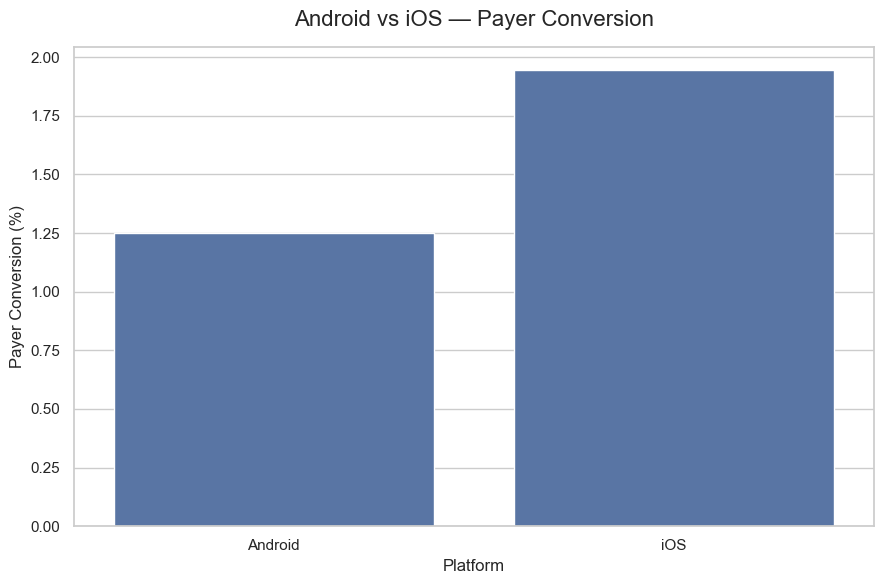

In [112]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=platform_monetization,
    x="created_platform",
    y="payer_conversion"
)

plt.title(
    "Android vs iOS — Payer Conversion",
    fontsize=16,
    pad=15
)

plt.xlabel("Platform")
plt.ylabel("Payer Conversion (%)")

plt.tight_layout()
plt.show()

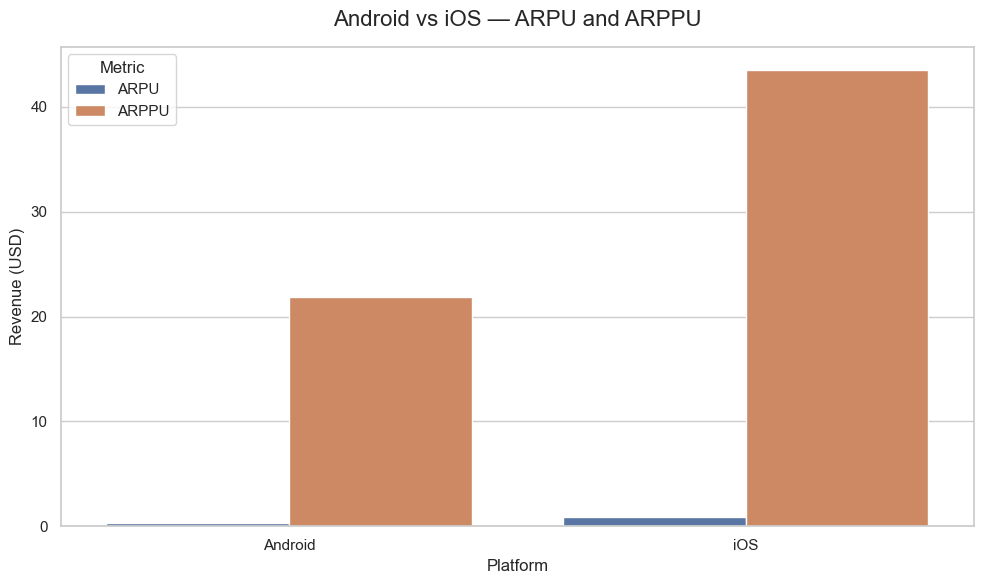

In [115]:
platform_monetization_plot = platform_monetization.melt(
    id_vars="created_platform",
    value_vars=["ARPU", "ARPPU"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=platform_monetization_plot,
    x="created_platform",
    y="value",
    hue="metric"
)

plt.title(
    "Android vs iOS — ARPU and ARPPU",
    fontsize=16,
    pad=15
)

plt.xlabel("Platform")
plt.ylabel("Revenue (USD)")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

Platform → Retention 📱📈

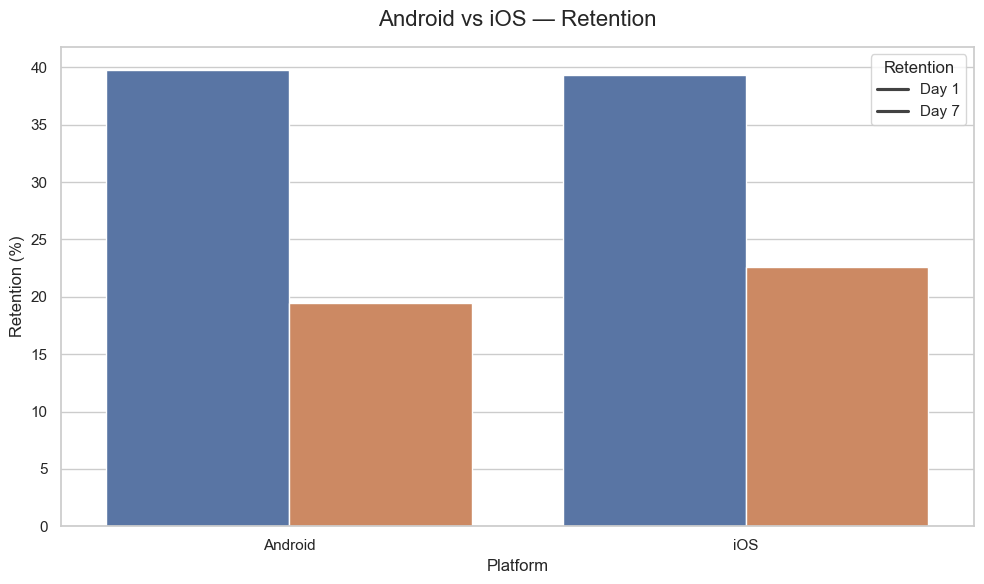

In [116]:
platform_retention_plot = platform_retention.melt(
    id_vars="created_platform",
    value_vars=["d1_retention", "d7_retention"],
    var_name="retention_day",
    value_name="retention"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=platform_retention_plot,
    x="created_platform",
    y="retention",
    hue="retention_day"
)

plt.title(
    "Android vs iOS — Retention",
    fontsize=16,
    pad=15
)

plt.xlabel("Platform")
plt.ylabel("Retention (%)")
plt.legend(
    title="Retention",
    labels=["Day 1", "Day 7"]
)

plt.tight_layout()
plt.show()

| Metric                |   Android |       iOS | What we observed                      |
| --------------------- | --------: | --------: | ------------------------------------- |
| Players               |    92,008 |    20,443 | Android has a much larger player base |
| Avg Day-0 Sessions    |      2.43 |      2.39 | Almost identical                      |
| Median Day-0 Sessions |         1 |         1 | Identical                             |
| Avg Day-0 Duration    | 19.71 min | 16.94 min | Android is higher                     |
| Median Day-0 Duration |  8.22 min |  5.27 min | Android is higher                     |
| D1 Retention          |    39.80% |    39.38% | Almost identical                      |
| D7 Retention          |    19.49% |    22.58% | iOS is higher                         |
| Payer Conversion      |     1.25% |     1.95% | iOS is higher                         |
| ARPU                  |     $0.27 |     $0.85 | iOS is higher                         |
| ARPPU                 |    $21.88 |    $43.56 | iOS is higher                         |


🎯 The Most Important Story

We can see three interesting patterns:

1. Engagement

Android players spent more time playing on Day 0:

19.71 vs. 16.94 minutes

However, the number of sessions was almost identical.

2. Retention

D1 retention was almost identical:

39.80% vs. 39.38%

But by D7:

19.49% vs. 22.58%

3. Monetization

The difference becomes more pronounced in monetization:

Payer Conversion: 1.25% → 1.95%

ARPU: $0.27 → $0.85

ARPPU: $21.88 → $43.56

🔥 Key Insight

Platform differences were not consistent across the player journey: Android showed higher early play duration, while iOS showed higher D7 retention and monetization metrics.

This is much more informative than simply saying “iOS is better.”

We are describing the behavioral pattern across the player journey rather than ranking the two platforms.


------------------------------------------------------

🧠 Final Business Insights

Data → Finding → Insight → Business Action

----------------------------------------------------------

# 🎮 Clash Royale — Final Business Findings

## 1. Player Acquisition / Player Base

### Finding

* The dataset contains **112,792 players**.
* Android: **92,253 players**
* iOS: **20,539 players**
* Approximately **82%** of players are on Android and **18%** on iOS.
* The number of new players declined over the course of 2016.

### Insight

Android represents a much larger share of the player base, while the volume of new player acquisition declined over the period.

### Business Actions

* Monitor **acquisition trends by platform and cohort**.
* If the pattern persists in newer data, investigate which **acquisition channels or markets** are associated with larger cohorts.
* Monitor **Android and iOS acquisition performance separately**.

> **Note:** The data alone cannot determine the cause of the decline in acquisition.


# 2. Player Engagement

## Finding

On Day 0:

* Median sessions = **1**
* Mean sessions = **2.43** on Android
* Mean sessions = **2.39** on iOS
* Median duration:

  * Android: **8.22 min**
  * iOS: **5.27 min**
* Mean duration:

  * Android: **19.71 min**
  * iOS: **16.94 min**

Both **session count** and **session duration** are **right-skewed**.

### Insight

A large share of player-days shows relatively low engagement, while a smaller group of players is much more active.

Session frequency is almost identical between Android and iOS, but Android players show longer Day-0 play duration.

### Business Actions

* Investigate the behavior of **highly engaged players** during the first hours and days.
* Compare **onboarding, early progression, and first-session experience** between highly engaged and low-engagement players.
* Investigate potential **drop-off points** in the early player experience among low-engagement players.


# 3. Engagement → Retention

This is one of the **most important findings of the entire project**.

### Finding

D7 retention by Day-0 session count:

| Day-0 Engagement | D7 Retention |
| ---------------- | -----------: |
| 1 session        |    **8.12%** |
| 2 sessions       |   **22.69%** |
| 3–4 sessions     |   **35.97%** |
| 5+ sessions      |   **55.34%** |

There is a substantial difference in D7 retention between **low-engagement** and **very-high-engagement** players.

### Insight

> **Higher Day-0 engagement is strongly associated with higher D7 retention.**

However, we do **not** claim that this relationship is causal. We are reporting an **association**, not saying that higher engagement *causes* higher retention.

### Business Actions

The product team can investigate which first-day features and experiences are associated with higher engagement:

* **Onboarding**
* **Tutorial**
* **Early progression**
* **Early rewards**
* **First battles**
* **Difficulty**
* **Content pacing**

### 🎯 Business Goal

> **Identify early-game behaviors and experiences associated with long-term retention.**


# 4. Overall Retention

### Finding

Overall retention:

| Metric |      Retention |
| ------ | -------------: |
| D1     |     **39.73%** |
| D7     |     **20.05%** |
| D14    |  Lower than D7 |
| D30    | Lower than D14 |

For example, for the January cohort:

* **D1 → 42.7%**
* **D7 → 23.4%**
* **D14 → 18.3%**
* **D30 → 13.3%**

### Insight

A substantial share of players leave the game during the first week, and retention continues to decline over time.

### Business Actions

* Focus on **early retention**, especially the gap between **D1 and D7**.
* Compare different cohorts in terms of their **early-game experience**.
* Compare the behavior of players who remain until **D7 and D30** with players who churn earlier.

### 🎯 Business Goal

> **Identify what differentiates players who remain engaged from those who churn during the early stages of the player journey.**


# 5. Cohort Retention

### Finding

Retention varies across monthly cohorts.

For example, **D30 retention** ranges approximately from:

**8.1% to 13.3%**

The January cohort also shows higher D1, D7, D14, and D30 retention compared with many later cohorts.

### Insight

Retention is **not consistent across cohorts**, suggesting that different cohorts may have experienced different player behaviors or acquisition and early-game conditions.

### Business Actions

For cohorts with different retention performance, investigate:

* **Acquisition source**
* **Platform mix**
* **Geography**
* **Engagement**
* **Early progression**
* **Monetization behavior**

This analysis can help identify **factors associated with differences in cohort performance**.


# 6. Retention → Monetization 💰

One of the **strongest findings in the project**.

### Finding

| D7 Status    | Payer Conversion |      ARPU |      ARPPU |
| ------------ | ---------------: | --------: | ---------: |
| D7 Retained  |        **5.31%** | **$1.72** | **$32.39** |
| Not Retained |        **0.40%** | **$0.05** | **$11.74** |

D7-retained players show:

* Higher **payer conversion**
* Higher **revenue per player**
* Higher **revenue per payer**

### Insight

> **D7-retained players show substantially higher monetization metrics than players who do not return by Day 7.**

This is important because **retention and monetization appear to be closely associated in this dataset**.

However, this does **not** mean that retention causes higher spending—or that spending causes retention.

### Business Action

Instead of treating retention and monetization as two completely separate problems:

> **Retention and monetization should be analyzed together.**

The product team can investigate which **early-game behaviors and experiences** are shared by **high-retention and high-value players**.


# 7. Engagement → Monetization 💰

### Finding

As Day-0 engagement increases:

| Engagement   | Payer Conversion |      ARPU |
| ------------ | ---------------: | --------: |
| 1 session    |            0.47% |     $0.15 |
| 2 sessions   |            1.24% |     $0.31 |
| 3–4 sessions |            2.24% |     $0.59 |
| 5+ sessions  |        **4.84%** | **$1.29** |

However, **ARPPU remains within a relatively similar range:**

**~$25–$32**

### Insight

Players with higher engagement are more likely to become **payers**, which is associated with higher **ARPU**. Meanwhile, spending among those who do pay is relatively more similar across engagement groups.

Therefore, the difference in revenue appears to be more closely associated with **payer conversion** than with a large difference in **spend per payer**.

### Business Actions

* Identify **early behaviors associated with payer conversion**.
* Investigate the **first-purchase experience**.
* Analyze when highly engaged players make their **first purchase**.
* Design and test **onboarding and offer experiments** for new players.

> **Key takeaway:** Higher engagement is associated with **more players converting to payers**, rather than dramatically higher spending among existing payers.


# 8. Platform → Engagement

### Finding

| Metric             |   Android |       iOS |
| ------------------ | --------: | --------: |
| Avg Day-0 Sessions |      2.43 |      2.39 |
| Median Sessions    |         1 |         1 |
| Avg Duration       | 19.71 min | 16.94 min |
| Median Duration    |  8.22 min |  5.27 min |

### Insight

The number of initial sessions is almost identical across platforms, but **Android players spend more time playing on Day 0**.

### Business Actions

This difference can be further investigated through factors such as:

* **Device characteristics**
* **Acquisition mix**
* **Player demographics**
* **Gameplay behavior**

> **Key takeaway:** Platform differences in early engagement appear more pronounced in **session duration** than in **session frequency**.


# 9. Platform → Retention

### Finding

| Platform | D1 Retention | D7 Retention |
| -------- | -----------: | -----------: |
| Android  |   **39.80%** |   **19.49%** |
| iOS      |   **39.38%** |   **22.58%** |

### Insight

D1 retention is very similar across the two platforms, but a larger difference appears by D7, with iOS showing higher retention.

Interestingly, Android players have higher Day-0 play duration, but this does not correspond to higher D7 retention.

### Business Action

Monitor retention by platform across different stages of the player journey and investigate which player behaviors and early-game experiences are associated with longer-term retention on iOS.


# 10. Platform → Monetization

### Finding

| Metric           | Android |        iOS |
| ---------------- | ------: | ---------: |
| Payer Conversion |   1.25% |  **1.95%** |
| ARPU             |   $0.27 |  **$0.85** |
| ARPPU            |  $21.88 | **$43.56** |

### Insight

In this dataset, iOS players show:

* Higher payer conversion.
* Higher ARPU.
* Higher ARPPU.

The differences in monetization metrics are substantially larger than the differences observed in session count across platforms.

### Business Action

* Monitor monetization metrics separately by platform.
* Compare payment behavior and purchase timing across Android and iOS.
* If additional data becomes available, evaluate pricing and offer performance at the platform level.
